Clean dataset and load it into colab

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)


In [11]:
df_raw = pd.read_csv(
    "/content/creditcard.csv",
    dtype=str,
    on_bad_lines="skip"
)

print("Raw dataset shape:", df_raw.shape)
df = df_raw.apply(pd.to_numeric, errors="coerce")

print("\nDataset after numeric conversion:")
print(df.shape)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Raw dataset shape: (284807, 31)

Dataset after numeric conversion:
(284807, 31)

Missing values:
Series([], dtype: int64)


In [12]:
missing_rows = df[df.isnull().any(axis=1)]

print("\nRows with missing values:", len(missing_rows))
df = df.dropna().copy()


Rows with missing values: 0


check data and fraud %

In [13]:
import matplotlib.pyplot as plt

print("\nClass distribution:")
print(df["Class"].value_counts())

fraud_count = (df["Class"] == 1).sum()
normal_count = (df["Class"] == 0).sum()

fraud_percentage = fraud_count / len(df) * 100

print("\nNormal transactions:", normal_count)
print("Fraud transactions:", fraud_count)
print("Fraud percentage:", fraud_percentage)

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Normal transactions: 284315
Fraud transactions: 492
Fraud percentage: 0.1727485630620034


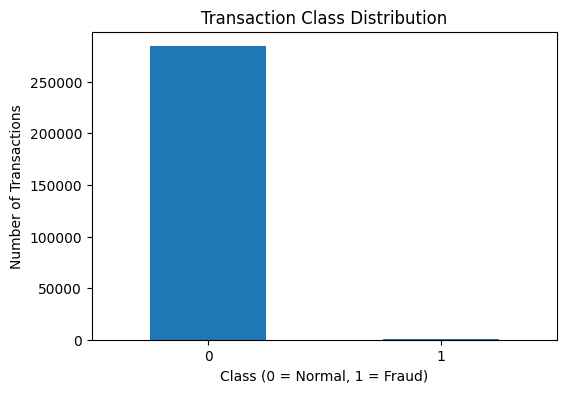

In [14]:
plt.figure(figsize=(6, 4))

df["Class"].value_counts().plot(kind="bar")

plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

separate dataset into test, train

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (227845, 30)
Test set: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


train random forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


Evaluate model

In [17]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

pr_auc = average_precision_score(y_test, y_prob)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("PR-AUC:", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Precision: 0.9605263157894737
Recall: 0.7448979591836735
F1-score: 0.8390804597701149
PR-AUC: 0.8541999432510914

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56861     3]
 [   25    73]]


Isolation forest

In [18]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train)

print("Isolation Forest training completed.")

Isolation Forest training completed.


In [19]:
iso_predictions = iso_model.predict(X_test)

iso_scores = -iso_model.decision_function(X_test)

In [20]:
iso_pr_auc = average_precision_score(
    y_test,
    iso_scores
)

print("Isolation Forest PR-AUC:", iso_pr_auc)

Isolation Forest PR-AUC: 0.21797227754191925


threshold check

In [21]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:

    y_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_threshold
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_results = pd.DataFrame(results)

print(threshold_results)

   Threshold  Precision    Recall        F1  False Positives  False Negatives
0        0.1   0.741379  0.877551  0.803738               30               12
1        0.2   0.857143  0.857143  0.857143               14               14
2        0.3   0.920455  0.826531  0.870968                7               17
3        0.4   0.951807  0.806122  0.872928                4               19
4        0.5   0.960526  0.744898  0.839080                3               25
5        0.6   0.972603  0.724490  0.830409                2               27
6        0.7   0.970149  0.663265  0.787879                2               33
7        0.8   0.966667  0.591837  0.734177                2               40
8        0.9   0.958333  0.469388  0.630137                2               52


drift detection

In [22]:
print("Minimum Time:", df["Time"].min())
print("Maximum Time:", df["Time"].max())

Minimum Time: 0.0
Maximum Time: 172792.0


In [23]:
df_time = df.sort_values("Time").reset_index(drop=True)

print("First transaction time:",
      df_time["Time"].iloc[0])

print("Last transaction time:",
      df_time["Time"].iloc[-1])

First transaction time: 0.0
Last transaction time: 172792.0


In [24]:
split_index = int(len(df_time) * 0.70)

reference_window = df_time.iloc[:split_index].copy()
later_window = df_time.iloc[split_index:].copy()

print("Reference window:", reference_window.shape)
print("Later window:", later_window.shape)

Reference window: (199364, 31)
Later window: (85443, 31)


In [25]:
from scipy.stats import ks_2samp

features = [
    col for col in df.columns
    if col != "Class"
]

drift_results = []

for feature in features:

    reference_values = reference_window[feature]
    later_values = later_window[feature]

    statistic, p_value = ks_2samp(
        reference_values,
        later_values
    )

    drift_results.append({
        "Feature": feature,
        "KS Statistic": statistic,
        "p-value": p_value
    })

drift_df = pd.DataFrame(drift_results)

print(drift_df)

   Feature  KS Statistic        p-value
0     Time      1.000000   0.000000e+00
1       V1      0.303643   0.000000e+00
2       V2      0.026233   3.451998e-36
3       V3      0.399748   0.000000e+00
4       V4      0.144490   0.000000e+00
5       V5      0.180992   0.000000e+00
6       V6      0.102018   0.000000e+00
7       V7      0.102065   0.000000e+00
8       V8      0.095474   0.000000e+00
9       V9      0.046231  1.589253e-111
10     V10      0.044984  1.312180e-105
11     V11      0.162594   0.000000e+00
12     V12      0.094623   0.000000e+00
13     V13      0.052417  2.922545e-143
14     V14      0.088616   0.000000e+00
15     V15      0.191524   0.000000e+00
16     V16      0.015160   2.271013e-12
17     V17      0.082696   0.000000e+00
18     V18      0.066501  2.057368e-230
19     V19      0.054218  2.963569e-153
20     V20      0.107443   0.000000e+00
21     V21      0.122015   0.000000e+00
22     V22      0.153919   0.000000e+00
23     V23      0.144349   0.000000e+00


In [26]:
drift_df = drift_df.sort_values(
    "KS Statistic",
    ascending=False
)

print(drift_df)

   Feature  KS Statistic        p-value
0     Time      1.000000   0.000000e+00
3       V3      0.399748   0.000000e+00
1       V1      0.303643   0.000000e+00
28     V28      0.257859   0.000000e+00
25     V25      0.232169   0.000000e+00
15     V15      0.191524   0.000000e+00
5       V5      0.180992   0.000000e+00
11     V11      0.162594   0.000000e+00
22     V22      0.153919   0.000000e+00
4       V4      0.144490   0.000000e+00
23     V23      0.144349   0.000000e+00
21     V21      0.122015   0.000000e+00
20     V20      0.107443   0.000000e+00
7       V7      0.102065   0.000000e+00
6       V6      0.102018   0.000000e+00
8       V8      0.095474   0.000000e+00
12     V12      0.094623   0.000000e+00
14     V14      0.088616   0.000000e+00
17     V17      0.082696   0.000000e+00
24     V24      0.066934  2.007897e-233
18     V18      0.066501  2.057368e-230
27     V27      0.065491  1.795873e-223
26     V26      0.061519  3.235960e-197
19     V19      0.054218  2.963569e-153


In [27]:
# Exclude Time because our windows were created chronologically
monitor_features = [
    col for col in df.columns
    if col not in ["Time", "Class"]
]

# Meaningful drift threshold
ks_threshold = 0.10

# Find features with meaningful drift
drifted_features = drift_df[
    (drift_df["Feature"].isin(monitor_features)) &
    (drift_df["KS Statistic"] >= ks_threshold)
]

number_drifted = len(drifted_features)
number_monitored = len(monitor_features)

drift_percentage = (
    number_drifted / number_monitored
) * 100

print("Monitored features:", number_monitored)
print("Drifted features:", number_drifted)
print("Drift percentage:", drift_percentage)

print("\nDrifted features:")
print(drifted_features[["Feature", "KS Statistic", "p-value"]])

# Retraining decision
if drift_percentage >= 20:
    print("\nDRIFT DETECTED")
    print("Retraining recommended.")
else:
    print("\nNO SIGNIFICANT DRIFT")
    print("No retraining required.")

Monitored features: 29
Drifted features: 14
Drift percentage: 48.275862068965516

Drifted features:
   Feature  KS Statistic  p-value
3       V3      0.399748      0.0
1       V1      0.303643      0.0
28     V28      0.257859      0.0
25     V25      0.232169      0.0
15     V15      0.191524      0.0
5       V5      0.180992      0.0
11     V11      0.162594      0.0
22     V22      0.153919      0.0
4       V4      0.144490      0.0
23     V23      0.144349      0.0
21     V21      0.122015      0.0
20     V20      0.107443      0.0
7       V7      0.102065      0.0
6       V6      0.102018      0.0

DRIFT DETECTED
Retraining recommended.


final detection function

In [30]:
FRAUD_THRESHOLD = 0.40


def detect_transaction(transaction):
    """
  detect suspicious transaction

  parameter: one transaction with 30 features

  return: random forest probability, isolation forest anomaly score, final decision
  """
    transaction_df = pd.DataFrame(
        [transaction],
        columns=X_train.columns
    )

    fraud_probability = rf_model.predict_proba(
        transaction_df
    )[0, 1]


    anomaly_score = -iso_model.decision_function(
        transaction_df
    )[0]


    if fraud_probability >= FRAUD_THRESHOLD:
        decision = "FRAUD / SUSPICIOUS"
    else:
        decision = "NORMAL"

    return {
        "Fraud Probability": fraud_probability,
        "Anomaly Score": anomaly_score,
        "Decision": decision
    }

test function

In [31]:
 # Take the first transaction from the test set
sample_transaction = X_test.iloc[0].values

result = detect_transaction(sample_transaction)

print("Transaction Result")
print("-------------------")
print("Fraud Probability:",
      result["Fraud Probability"])

print("Anomaly Score:",
      result["Anomaly Score"])

print("Decision:",
      result["Decision"])

print("Actual Class:",
      y_test.iloc[0])

Transaction Result
-------------------
Fraud Probability: 0.0
Anomaly Score: -0.09785723231158855
Decision: NORMAL
Actual Class: 0


In [32]:


def check_drift(
    reference_data,
    new_data,
    ks_threshold=0.10,
    drift_percentage_threshold=20
):

    monitor_features = [
        col for col in reference_data.columns
        if col not in ["Time", "Class"]
    ]

    drift_results = []

    for feature in monitor_features:

        statistic, p_value = ks_2samp(
            reference_data[feature],
            new_data[feature]
        )

        drift_results.append({
            "Feature": feature,
            "KS Statistic": statistic,
            "p-value": p_value
        })

    drift_results = pd.DataFrame(drift_results)

    drifted_features = drift_results[
        drift_results["KS Statistic"] >= ks_threshold
    ]

    drift_percentage = (
        len(drifted_features)
        / len(monitor_features)
    ) * 100

    if drift_percentage >= drift_percentage_threshold:
        alert = True
        message = "DRIFT DETECTED - RETRAINING RECOMMENDED"
    else:
        alert = False
        message = "NO SIGNIFICANT DRIFT"

    return {
        "Drift Results": drift_results,
        "Drifted Features": drifted_features,
        "Drift Percentage": drift_percentage,
        "Retraining Alert": alert,
        "Message": message
    }

In [33]:
drift_result = check_drift(
    reference_window,
    later_window
)

print("Drift Percentage:",
      drift_result["Drift Percentage"])

print("Retraining Alert:",
      drift_result["Retraining Alert"])

print("Message:",
      drift_result["Message"])

Drift Percentage: 48.275862068965516
Retraining Alert: True
Message: DRIFT DETECTED - RETRAINING RECOMMENDED
